In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving 1776250375-P2-Healthcare Analytics for Doctor Visits.csv to 1776250375-P2-Healthcare Analytics for Doctor Visits.csv


In [4]:
import os

print(os.listdir())

['.config', '1776250375-P2-Healthcare Analytics for Doctor Visits.csv', 'sample_data']


In [6]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [7]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [8]:
df.shape

(5190, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [10]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


In [12]:
df.duplicated().sum()

np.int64(0)

**Univariate Analysis**: Doctor Visits Distribution

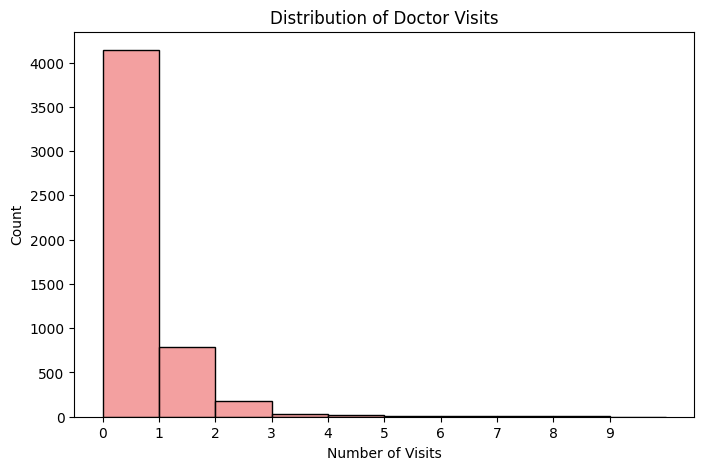

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

**Univariate Analysis**: Gender Distribution

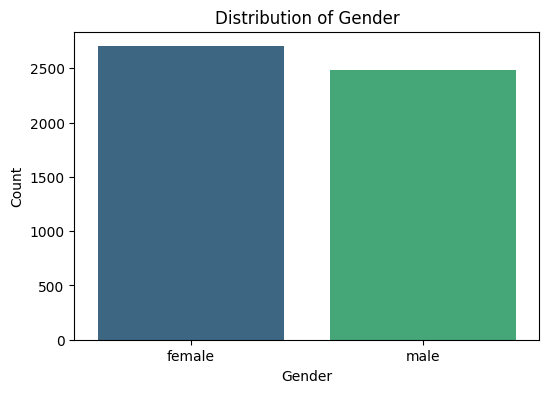

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

**Univariate Analysis**: Age Distribution

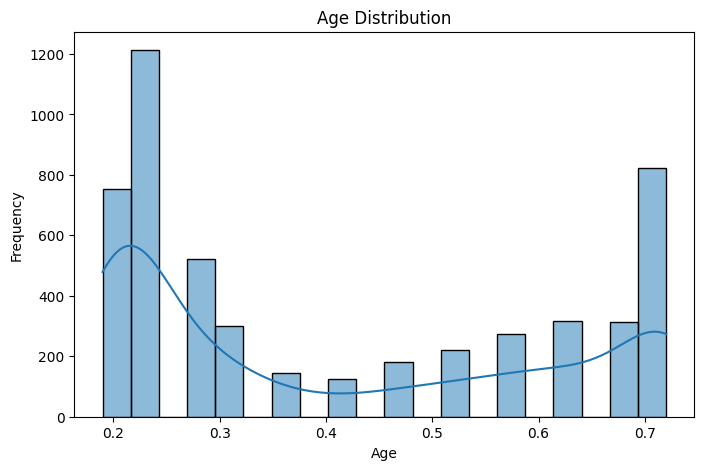

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', bins=20, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [16]:
gender_visits = df.groupby('gender')['visits'].agg(
    ['count', 'mean', 'median']
)

gender_visits

,count,mean,median
gender,,,
female,2702,0.361954,0.0
male,2488,0.236334,0.0


,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


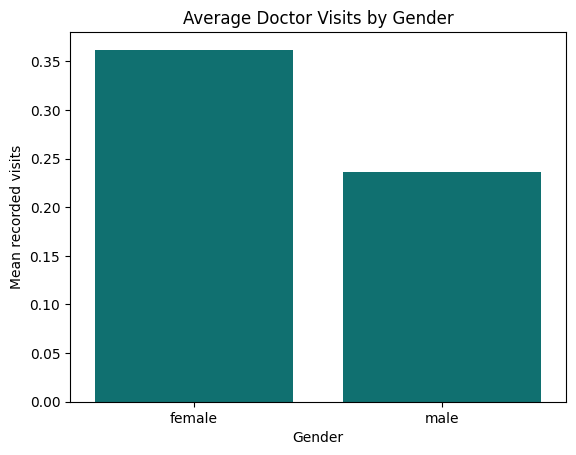

In [30]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

In [18]:
illness_visits = df.groupby('illness')['visits'].agg(
    ['count', 'mean', 'median']
)

illness_visits

,count,mean,median
illness,,,
0,1554,0.078507,0.0
1,1638,0.295482,0.0
2,946,0.403805,0.0
3,542,0.420664,0.0
4,274,0.576642,0.0
5,236,0.813559,0.0


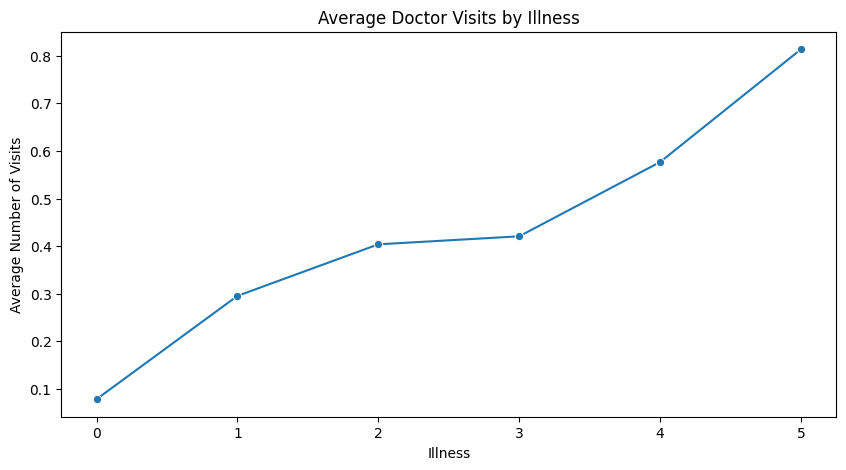

In [19]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x='illness',
    y='visits',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title('Average Doctor Visits by Illness')
plt.xlabel('Illness')
plt.ylabel('Average Number of Visits')

plt.show()

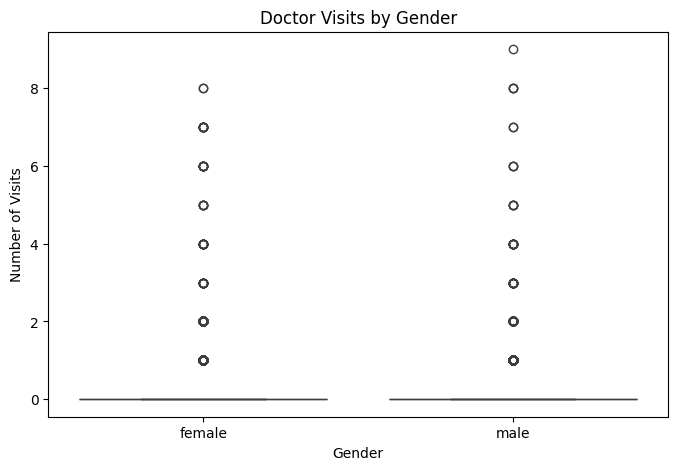

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='gender', y='visits')

plt.title('Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')

plt.show()

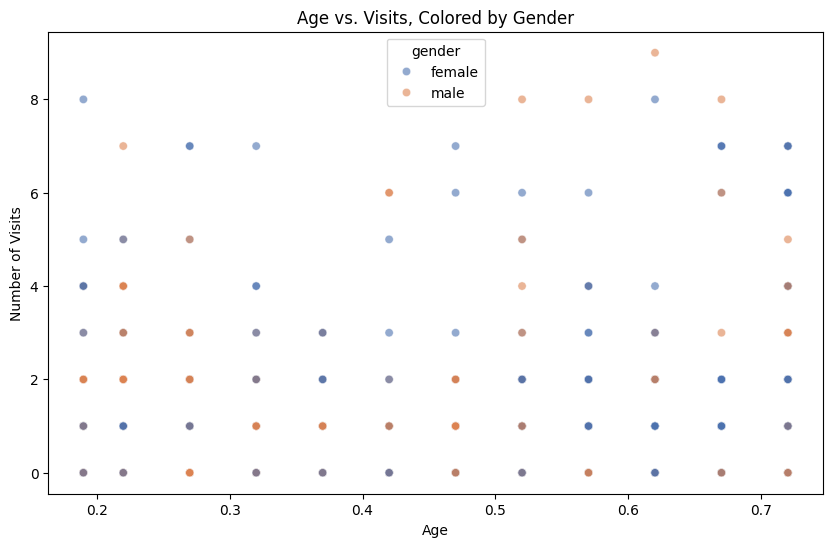

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

In [23]:
chronic_visits = df.groupby('nchronic')['visits'].agg(
    ['count', 'mean', 'median']
)

chronic_visits

,count,mean,median
nchronic,,,
no,3098,0.272111,0.0
yes,2092,0.345602,0.0


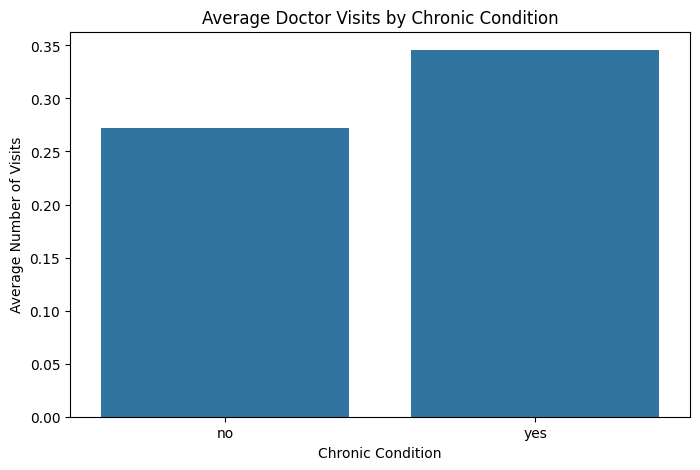

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='nchronic',
    y='visits',
    estimator='mean',
    errorbar=None
)

plt.title('Average Doctor Visits by Chronic Condition')
plt.xlabel('Chronic Condition')
plt.ylabel('Average Number of Visits')

plt.show()

In [25]:
print("Total patient records:", len(df))
print("Average doctor visits:", df['visits'].mean())
print("Maximum doctor visits:", df['visits'].max())
print("Average patient age:", df['age'].mean())
print("Most common gender:", df['gender'].mode()[0])
print("Most common illness level:", df['illness'].mode()[0])

Total patient records: 5190
Average doctor visits: 0.3017341040462428
Maximum doctor visits: 9
Average patient age: 0.40638535645472057
Most common gender: female
Most common illness level: 1


In [26]:
summary = pd.DataFrame({
    'Metric': [
        'Total Patient Records',
        'Average Doctor Visits',
        'Maximum Doctor Visits',
        'Average Patient Age'
    ],
    'Value': [
        len(df),
        round(df['visits'].mean(), 2),
        df['visits'].max(),
        round(df['age'].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Patient Records,5190.00
1,Average Doctor Visits,0.30
2,Maximum Doctor Visits,9.00
3,Average Patient Age,0.41


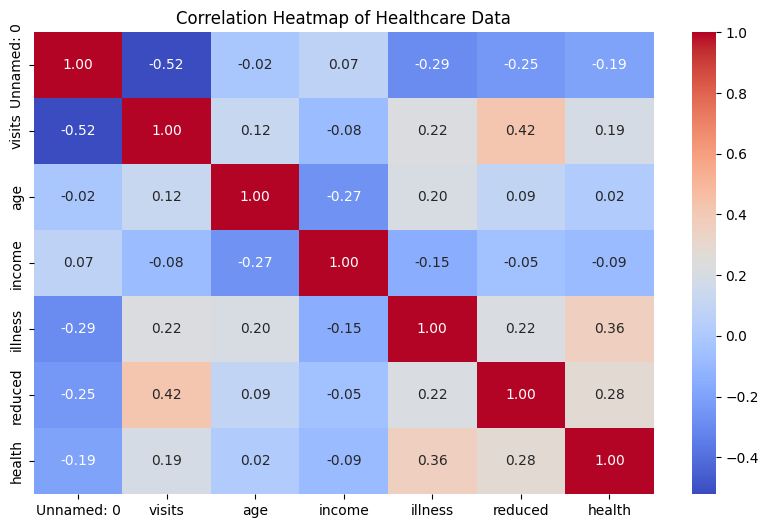

In [27]:
plt.figure(figsize=(10, 6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Healthcare Data')
plt.show()